Plot saved as 'multi_metric_line_plot_with_shaded_regions.png' and '.pdf'


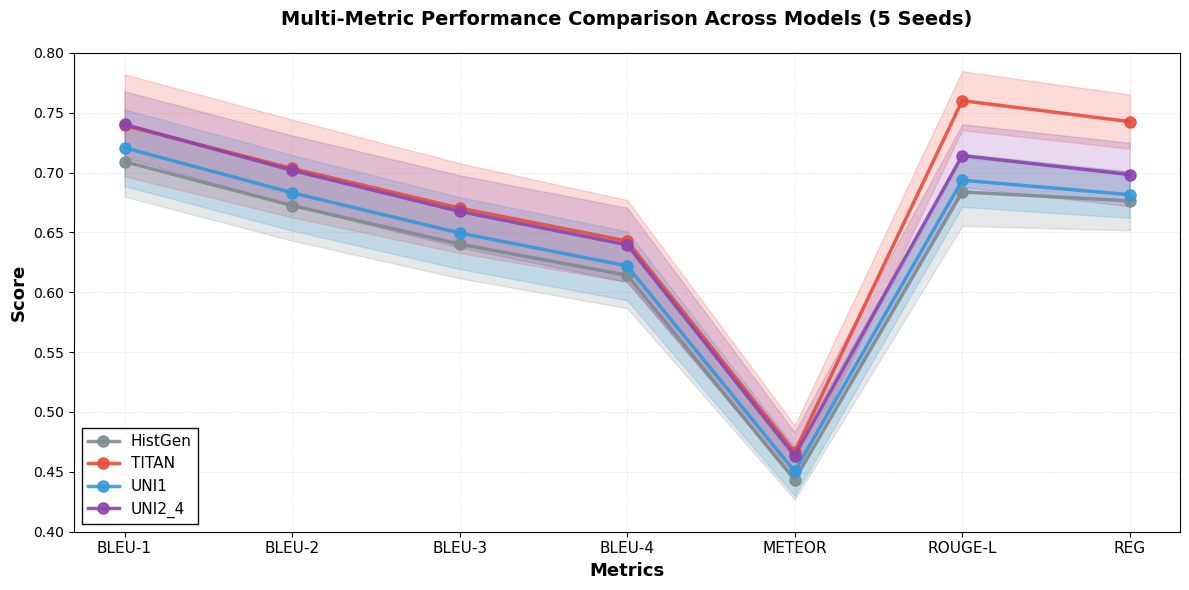

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# Function to parse mean ± std format
def parse_mean_std(value_str):
    parts = value_str.split('±')
    mean = float(parts[0].strip())
    std = float(parts[1].strip())
    return mean, std

# Read the CSV files
corpus_df = pd.read_csv('corpus_scores_summary_formatted.csv')
reg_df = pd.read_csv('reg_scores_summary_formatted.csv')

# Get models and metrics
models = corpus_df['Model'].tolist()
metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'METEOR', 'ROUGE-L', 'REG']

# Define color palette
model_colors = {
    'HistGen': '#7f8c8d',      
    'UNI1': '#3498db',         
    'UNI2_4': '#8e44ad',       
    'TITAN': "#e74c3c"         
}

# Extract data for each model
plot_data = {model: {'means': [], 'stds': []} for model in models}

for model in models:
    # Get corpus metrics (BLEU-1 through ROUGE-L)
    for metric in metrics[:-1]:
        value_str = corpus_df.loc[corpus_df['Model'] == model, metric].values[0]
        mean, std = parse_mean_std(value_str)
        plot_data[model]['means'].append(mean)
        plot_data[model]['stds'].append(std)

    # Add REG score
    reg_value_str = reg_df.loc[reg_df['Model'] == model, 'REG'].values[0]
    mean, std = parse_mean_std(reg_value_str)
    plot_data[model]['means'].append(mean)
    plot_data[model]['stds'].append(std)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))

# Plot each model with shaded regions
for model in models:
    means = np.array(plot_data[model]['means'])
    stds = np.array(plot_data[model]['stds'])

    color = model_colors[model]

    # Plot line
    ax.plot(x, means, marker='o', linewidth=2.5, markersize=8, 
            label=model, color=color, alpha=0.9)

    # Add shaded region for std
    ax.fill_between(x, means - stds, means + stds, 
                     alpha=0.2, color=color)

# Customize plot
ax.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Multi-Metric Performance Comparison Across Models (5 Seeds)', 
             fontsize=14, fontweight='bold', pad=20)

# Set x-axis
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)

# Set y-axis
ax.set_ylim(0.4, 0.8)
ax.set_yticks(np.arange(0.4, 0.85, 0.05))
ax.tick_params(axis='y', labelsize=10)

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Legend
ax.legend(loc='lower left', fontsize=11, framealpha=0.95, 
          edgecolor='black', fancybox=False)

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig('multi_metric_line_plot_with_shaded_regions.png', dpi=300, bbox_inches='tight')
plt.savefig('multi_metric_line_plot_with_shaded_regions.pdf', dpi=300, bbox_inches='tight')
print("Plot saved as 'multi_metric_line_plot_with_shaded_regions.png' and '.pdf'")
plt.show()

In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Function to parse mean ± std format
def parse_mean_std(value_str):
    parts = value_str.split('±')
    mean = float(parts[0].strip())
    std = float(parts[1].strip())
    return mean, std

# Read the CSV files
corpus_df = pd.read_csv('corpus_scores_summary_formatted.csv')
reg_df = pd.read_csv('reg_scores_summary_formatted.csv')

# Get models and metrics
models = corpus_df['Model'].tolist()
metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'METEOR', 'ROUGE-L', 'REG']

# Define color palette
model_colors = {
    'HistGen': '#7f8c8d',      # Gray - baseline
    'UNI1': '#3498db',         # Blue - intermediate
    'UNI2_4': '#8e44ad',       # Purple - better intermediate
    'TITAN': '#e74c3c'         # Red - best performer
}

# Extract data for each model
plot_data = {model: {'means': [], 'stds': []} for model in models}

for model in models:
    # Get corpus metrics (BLEU-1 through ROUGE-L)
    for metric in metrics[:-1]:
        value_str = corpus_df.loc[corpus_df['Model'] == model, metric].values[0]
        mean, std = parse_mean_std(value_str)
        plot_data[model]['means'].append(mean)
        plot_data[model]['stds'].append(std)

    # Add REG score
    reg_value_str = reg_df.loc[reg_df['Model'] == model, 'REG'].values[0]
    mean, std = parse_mean_std(reg_value_str)
    plot_data[model]['means'].append(mean)
    plot_data[model]['stds'].append(std)

print("Data loaded successfully!")
print(f"Models: {models}")
print(f"Metrics: {metrics}")

# ============================================================
# PART 1: Individual plots for each model (with shaded regions)
# ============================================================

for model in models:
    means = np.array(plot_data[model]['means'])
    stds = np.array(plot_data[model]['stds'])
    upper_bound = means + stds
    lower_bound = means - stds
    color = model_colors[model]

    fig = go.Figure()

    # Add shaded region (fill between upper and lower bounds)
    fig.add_trace(go.Scatter(
        x=metrics + metrics[::-1],  # x, then x reversed
        y=list(upper_bound) + list(lower_bound[::-1]),  # upper, then lower reversed
        fill='toself',
        fillcolor=color,
        opacity=0.2,
        line=dict(width=0),
        showlegend=True,
        name='±1 Std',
        hoverinfo='skip'
    ))

    # Add main line with markers
    fig.add_trace(go.Scatter(
        x=metrics,
        y=means,
        mode='lines+markers',
        name=model,
        line=dict(color=color, width=3),
        marker=dict(size=10, color=color, line=dict(width=2, color='white')),
        hovertemplate='<b>%{x}</b><br>Score: %{y:.4f}<br>±%{customdata:.4f}<extra></extra>',
        customdata=stds
    ))

    # Update layout
    fig.update_layout(
        title=dict(
            text=f'<b>{model} Performance Across Metrics (5 Seeds)</b>',
            font=dict(size=16),
            x=0.5,
            xanchor='center'
        ),
        xaxis=dict(
        title=dict(
            text='<b>Metrics</b>',
            font=dict(size=14)
        ),
        tickfont=dict(size=12),
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128,128,128,0.2)'
        ),
        yaxis=dict(
        title=dict(
            text='<b>Score</b>',
            font=dict(size=14)
        ),
        tickfont=dict(size=12),
        range=[0.4, 0.8],
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128,128,128,0.2)'
        ),
        width=1200,
        height=600,
        hovermode='x unified',
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(
            x=0.02,
            y=0.02,
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='black',
            borderwidth=1,
            font=dict(size=11)
        )
    )

    # Save interactive HTML
    fig.write_html(f'model_{model.lower()}_individual.html')

    # Save static image for thesis (PDF via kaleido)
    #fig.write_image(f'model_{model.lower()}_individual.pdf', width=1200, height=600, scale=2)
    #fig.write_image(f'model_{model.lower()}_individual.png', width=1200, height=600, scale=2)

    print(f"✓ Created plots for {model}")

# ============================================================
# PART 2: Combined overview plot (all models, NO shading)
# ============================================================

fig_overview = go.Figure()

for model in models:
    means = np.array(plot_data[model]['means'])
    stds = np.array(plot_data[model]['stds'])
    color = model_colors[model]

    fig_overview.add_trace(go.Scatter(
        x=metrics,
        y=means,
        mode='lines+markers',
        name=model,
        line=dict(color=color, width=3),
        marker=dict(size=10, color=color, line=dict(width=2, color='white')),
        hovertemplate='<b>%{fullData.name}</b><br>Metric: %{x}<br>Score: %{y:.4f}<br>±%{customdata:.4f}<extra></extra>',
        customdata=stds
    ))

# Update layout for overview
fig_overview.update_layout(
    title=dict(
        text='<b>Multi-Metric Performance Comparison Across All Models (5 Seeds)</b>',
        font=dict(size=16),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
    title=dict(
        text='<b>Metrics</b>',
        font=dict(size=14)
    ),
    tickfont=dict(size=12),
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128,128,128,0.2)'
    ),
    yaxis=dict(
    title=dict(
        text='<b>Score</b>',
        font=dict(size=14)
    ),
    tickfont=dict(size=12),
    range=[0.4, 0.8],
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128,128,128,0.2)'
    ),  
    width=1200,
    height=600,
    hovermode='closest',
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        x=0.02,
        y=0.02,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=11)
    )
)

# Save combined overview
fig_overview.write_html('all_models_overview.html')
#fig_overview.write_image('all_models_overview.pdf', width=1200, height=600, scale=2)
#fig_overview.write_image('all_models_overview.png', width=1200, height=600, scale=2)

print("\n✓ Created combined overview plot")
print("\n" + "="*70)
print("SUMMARY OF GENERATED FILES:")
print("="*70)
print("Individual Model Plots (with shaded regions):")
for model in models:
    print(f"  - model_{model.lower()}_individual.html (interactive)")
    print(f"  - model_{model.lower()}_individual.pdf (for thesis)")
    print(f"  - model_{model.lower()}_individual.png (backup)")
print("\nCombined Overview Plot (no shading):")
print("  - all_models_overview.html (interactive)")
print("  - all_models_overview.pdf (for thesis)")
print("  - all_models_overview.png (backup)")
print("="*70)
print("\nFor Jupyter: Open the .html files in your browser")
print("For Thesis: Use the .pdf files in Overleaf")

Data loaded successfully!
Models: ['HistGen', 'TITAN', 'UNI1', 'UNI2_4']
Metrics: ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'METEOR', 'ROUGE-L', 'REG']
✓ Created plots for HistGen
✓ Created plots for TITAN
✓ Created plots for UNI1
✓ Created plots for UNI2_4

✓ Created combined overview plot

SUMMARY OF GENERATED FILES:
Individual Model Plots (with shaded regions):
  - model_histgen_individual.html (interactive)
  - model_histgen_individual.pdf (for thesis)
  - model_histgen_individual.png (backup)
  - model_titan_individual.html (interactive)
  - model_titan_individual.pdf (for thesis)
  - model_titan_individual.png (backup)
  - model_uni1_individual.html (interactive)
  - model_uni1_individual.pdf (for thesis)
  - model_uni1_individual.png (backup)
  - model_uni2_4_individual.html (interactive)
  - model_uni2_4_individual.pdf (for thesis)
  - model_uni2_4_individual.png (backup)

Combined Overview Plot (no shading):
  - all_models_overview.html (interactive)
  - all_models_overview.pdf

FINAL CODE BELOW

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib

# Set matplotlib to use high-quality settings
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Function to parse mean ± std format
def parse_mean_std(value_str):
    parts = value_str.split('±')
    mean = float(parts[0].strip())
    std = float(parts[1].strip())
    return mean, std

# Read the CSV files
corpus_df = pd.read_csv('corpus_scores_summary_formatted.csv')
reg_df = pd.read_csv('reg_scores_summary_formatted.csv')

# Get models and metrics
models = corpus_df['Model'].tolist()
metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'METEOR', 'ROUGE-L', 'REG']

# Define color palette (EXACT SAME for both Plotly and Matplotlib)
model_colors = {
    'HistGen': '#7f8c8d',
    'UNI': '#3498db',
    'UNI2': '#8e44ad',
    'TITAN': '#e74c3c'
}

# Extract data for each model
plot_data = {model: {'means': [], 'stds': []} for model in models}

for model in models:
    for metric in metrics[:-1]:
        value_str = corpus_df.loc[corpus_df['Model'] == model, metric].values[0]
        mean, std = parse_mean_std(value_str)
        plot_data[model]['means'].append(mean)
        plot_data[model]['stds'].append(std)

    reg_value_str = reg_df.loc[reg_df['Model'] == model, 'REG'].values[0]
    mean, std = parse_mean_std(reg_value_str)
    plot_data[model]['means'].append(mean)
    plot_data[model]['stds'].append(std)

print("Data loaded successfully!")
print(f"Models: {models}")
print(f"Metrics: {metrics}\n")

# Store all Plotly figures for display
all_plotly_figures = []

# ============================================================
# PART 1: Individual plots for each model
# ============================================================

for model in models:
    means = np.array(plot_data[model]['means'])
    stds = np.array(plot_data[model]['stds'])
    upper_bound = means + stds
    lower_bound = means - stds
    color = model_colors[model]
    x_pos = np.arange(len(metrics))

    # --- PLOTLY VERSION (Interactive) ---
    fig_plotly = go.Figure()

    # Add shaded region
    fig_plotly.add_trace(go.Scatter(
        x=metrics + metrics[::-1],
        y=list(upper_bound) + list(lower_bound[::-1]),
        fill='toself',
        fillcolor=color,
        opacity=0.2,
        line=dict(width=0),
        showlegend=True,
        name='±1 Std',
        hoverinfo='skip'
    ))

    # Add main line with markers
    fig_plotly.add_trace(go.Scatter(
        x=metrics,
        y=means,
        mode='lines+markers',
        name=model,
        line=dict(color=color, width=3),
        marker=dict(size=10, color=color, line=dict(width=2, color='white')),
        hovertemplate='<b>%{x}</b><br>Score: %{y:.4f}<br>±%{customdata:.4f}<extra></extra>',
        customdata=stds
    ))

    fig_plotly.update_layout(
        title=dict(
            text=f'<b>{model} Performance Across Metrics (5 Seeds)</b>',
            font=dict(size=16),
            x=0.5,
            xanchor='center'
        ),
        xaxis=dict(
            title=dict(text='<b>Metrics</b>', font=dict(size=14)),
            tickfont=dict(size=12),
            showgrid=True,
            gridwidth=1,
            gridcolor='rgba(128,128,128,0.2)'
        ),
        yaxis=dict(
            title=dict(text='<b>Score</b>', font=dict(size=14)),
            tickfont=dict(size=12),
            range=[0.4, 0.8],
            showgrid=True,
            gridwidth=1,
            gridcolor='rgba(128,128,128,0.2)'
        ),
        width=1200,
        height=600,
        margin=dict(l=80, r=40, t=80, b=80, pad=0),
        hovermode='x unified',
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(
            x=0.02,
            y=0.02,
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='black',
            borderwidth=1,
            font=dict(size=11)
        )
    )

    # Save interactive HTML
    fig_plotly.write_html(f'model_{model.lower()}_individual.html')
    all_plotly_figures.append((model, fig_plotly))

    # --- MATPLOTLIB VERSION (High-quality PDF/PNG) ---
    fig_mpl, ax = plt.subplots(figsize=(12, 6))

    # Plot shaded region
    ax.fill_between(x_pos, lower_bound, upper_bound, 
                     alpha=0.2, color=color, label='±1 Std')

    # Plot main line with markers
    ax.plot(x_pos, means, marker='o', linewidth=2.5, markersize=8,
            color=color, label=model, markeredgewidth=2, markeredgecolor='white')

    # Styling
    ax.set_xlabel('Metrics', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=14, fontweight='bold')
    ax.set_title(f'{model} Performance Across Metrics', 
                 fontsize=16, fontweight='bold', pad=20)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(metrics, fontsize=12)
    ax.set_ylim(0.4, 0.8)
    ax.set_yticks(np.arange(0.4, 0.85, 0.05))
    ax.tick_params(axis='y', labelsize=11)

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.set_facecolor('white')

    ax.legend(loc='lower left', fontsize=11, framealpha=0.95,
              edgecolor='black', fancybox=False)

    plt.tight_layout()

    # Save high-quality PDF and PNG
    plt.savefig(f'model_{model.lower()}_individual.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'model_{model.lower()}_individual.png', dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✓ Created plots for {model}")

# ============================================================
# PART 2: Combined overview plot (all models, NO shading)
# ============================================================

# --- PLOTLY VERSION (Interactive) ---
fig_overview_plotly = go.Figure()

for model in models:
    means = np.array(plot_data[model]['means'])
    stds = np.array(plot_data[model]['stds'])
    color = model_colors[model]

    fig_overview_plotly.add_trace(go.Scatter(
        x=metrics,
        y=means,
        mode='lines+markers',
        name=model,
        line=dict(color=color, width=3),
        marker=dict(size=10, color=color, line=dict(width=2, color='white')),
        hovertemplate='<b>%{fullData.name}</b><br>Metric: %{x}<br>Score: %{y:.4f}<br>±%{customdata:.4f}<extra></extra>',
        customdata=stds
    ))

fig_overview_plotly.update_layout(
    title=dict(
        text='<b>Multi-Metric Performance Comparison Across All Models (5 Seeds)</b>',
        font=dict(size=16),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='<b>Metrics</b>', font=dict(size=14)),
        tickfont=dict(size=12),
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128,128,128,0.2)'
    ),
    yaxis=dict(
        title=dict(text='<b>Score</b>', font=dict(size=14)),
        tickfont=dict(size=12),
        range=[0.4, 0.8],
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128,128,128,0.2)'
    ),
    width=1200,
    height=600,
    margin=dict(l=80, r=40, t=80, b=80, pad=0),
    hovermode='closest',
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        x=0.02,
        y=0.02,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=11)
    )
)

fig_overview_plotly.write_html('all_models_overview.html')
all_plotly_figures.append(('Overview', fig_overview_plotly))

# --- MATPLOTLIB VERSION (High-quality PDF/PNG) ---
fig_mpl, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(metrics))

for model in models:
    means = np.array(plot_data[model]['means'])
    color = model_colors[model]

    ax.plot(x_pos, means, marker='o', linewidth=2.5, markersize=8,
            color=color, label=model, markeredgewidth=2, markeredgecolor='white')

# Styling
ax.set_xlabel('Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('Multi-Metric Performance Comparison Across All Models', 
             fontsize=16, fontweight='bold', pad=20)

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.4, 0.8)
ax.set_yticks(np.arange(0.4, 0.85, 0.05))
ax.tick_params(axis='y', labelsize=11)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
ax.set_facecolor('white')

ax.legend(loc='lower left', fontsize=11, framealpha=0.95,
          edgecolor='black', fancybox=False)

plt.tight_layout()

plt.savefig('all_models_overview.pdf', dpi=300, bbox_inches='tight')
plt.savefig('all_models_overview.png', dpi=300, bbox_inches='tight')
plt.close()

print("\n✓ Created combined overview plot")

# ============================================================
# PART 3: Display all Plotly figures in Jupyter notebook
# ============================================================

print("\n" + "="*70)
print("DISPLAYING ALL INTERACTIVE FIGURES IN JUPYTER")
print("="*70)

for model_name, figure in all_plotly_figures:
    print(f"\nShowing: {model_name}")
    figure.show()

print("\n" + "="*70)
print("SUMMARY OF GENERATED FILES:")
print("="*70)
print("\nIndividual Model Plots:")
for model in models:
    print(f"  {model}:")
    print(f"    - model_{model.lower()}_individual.html (Plotly - interactive)")
    print(f"    - model_{model.lower()}_individual.pdf (Matplotlib - THESIS)")
    print(f"    - model_{model.lower()}_individual.png (Matplotlib - backup)")
print("\nCombined Overview Plot:")
print("    - all_models_overview.html (Plotly - interactive)")
print("    - all_models_overview.pdf (Matplotlib - THESIS)")
print("    - all_models_overview.png (Matplotlib - backup)")
print("="*70)
print("\n✓ Plotly: Interactive HTML with hover tooltips")
print("✓ Matplotlib: Vector PDF (300 DPI) - NO Chrome needed!")
print("✓ Same colors, titles, legends, layout across both")
print("="*70)

Data loaded successfully!
Models: ['HistGen', 'TITAN', 'UNI', 'UNI2']
Metrics: ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'METEOR', 'ROUGE-L', 'REG']

✓ Created plots for HistGen
✓ Created plots for TITAN
✓ Created plots for UNI
✓ Created plots for UNI2

✓ Created combined overview plot

DISPLAYING ALL INTERACTIVE FIGURES IN JUPYTER

Showing: HistGen



Showing: TITAN



Showing: UNI



Showing: UNI2



Showing: Overview



SUMMARY OF GENERATED FILES:

Individual Model Plots:
  HistGen:
    - model_histgen_individual.html (Plotly - interactive)
    - model_histgen_individual.pdf (Matplotlib - THESIS)
    - model_histgen_individual.png (Matplotlib - backup)
  TITAN:
    - model_titan_individual.html (Plotly - interactive)
    - model_titan_individual.pdf (Matplotlib - THESIS)
    - model_titan_individual.png (Matplotlib - backup)
  UNI:
    - model_uni_individual.html (Plotly - interactive)
    - model_uni_individual.pdf (Matplotlib - THESIS)
    - model_uni_individual.png (Matplotlib - backup)
  UNI2:
    - model_uni2_individual.html (Plotly - interactive)
    - model_uni2_individual.pdf (Matplotlib - THESIS)
    - model_uni2_individual.png (Matplotlib - backup)

Combined Overview Plot:
    - all_models_overview.html (Plotly - interactive)
    - all_models_overview.pdf (Matplotlib - THESIS)
    - all_models_overview.png (Matplotlib - backup)

✓ Plotly: Interactive HTML with hover tooltips
✓ Matplotlib: V